In [26]:
#load in packages  
import mne
import matplotlib.pyplot as plt
import pandas as pd
import os
import numpy as np
import os.path as op
import warnings
from mne_bids import (
    BIDSPath,
    make_dataset_description,
    print_dir_tree,
    read_raw_bids,
)
from mne.preprocessing import find_bad_channels_maxwell
import sys
import scipy

warnings.filterwarnings('ignore')

In [27]:
#load in epochs
subject = '01'
session = '01'
task = 'face'
run = '01'

bids_root = '/Users/rekaforgo/Documents/Bachelor2025/'
deriv_root = op.join(bids_root, 'derivatives', 'preprocessing')

epochs = mne.read_epochs(op.join(deriv_root, f'sub-{subject}', f'ses-{session}', 'meg', f'sub-{subject}_ses-{session}_task-{task}_run-{run}_epo.fif'))


Reading /Users/rekaforgo/Documents/Bachelor2025/derivatives/preprocessing/sub-01/ses-01/meg/sub-01_ses-01_task-face_run-01_epo.fif ...
    Found the data of interest:
        t =    -200.00 ...     800.00 ms
        0 CTF compensation matrices available
Not setting metadata
256 matching events found
No baseline correction applied
0 projection items activated


In [28]:
epochs.load_data()

<EpochsFIF | 256 events (all good), -0.2 – 0.8 s (baseline -0.2 – 0 s), ~125.2 MiB, data loaded,
 '1': 4
 '2': 4
 '3': 4
 '4': 4
 '5': 4
 '6': 4
 '7': 4
 '8': 4
 '9': 4
 '10': 4
 and 54 more events ...>

In [29]:
#set up event list from epochs
events = epochs.events  

stim_ids = events[:, 2]
md = pd.DataFrame(dict(stim_id=stim_ids))
md['race']    = np.where(md.stim_id <= 32, 1, 2)
md['gender']  = np.where(((md.stim_id - 1) % 32) < 16, 1, 2)
md['age']     = np.where(((md.stim_id - 1) // 8) % 2 == 0, 1, 2)
md['emotion'] = np.where(((md.stim_id - 1) // 4) % 2 == 0, 1, 2)

epochs.metadata = md
print(epochs.metadata.head())

Adding metadata with 5 columns
   stim_id  race  gender  age  emotion
0       18     1       2    1        1
1       26     1       2    2        1
2        8     1       1    1        2
3       20     1       2    1        1
4       21     1       2    1        2


In [30]:
#following flux pipeline for time-frequency decomposition
freqs = np.arange(2, 31, 1)
n_cycles = freqs / 2 
time_bandwidth = 2.0

In [31]:

tfr_slow_neutral =  mne.time_frequency.tfr_multitaper(
    epochs['emotion == 1'], 
    freqs=freqs, 
    n_cycles=n_cycles,
    time_bandwidth=time_bandwidth, 
    picks = 'meg',
    use_fft=True, 
    return_itc=False,
    average=True, 
    decim=2,
    n_jobs = -1,
    verbose=True)

tfr_slow_joy = mne.time_frequency.tfr_multitaper(
    epochs['emotion == 2'], 
    freqs=freqs, 
    n_cycles=n_cycles,
    time_bandwidth=time_bandwidth, 
    picks = 'meg',
    use_fft=True, 
    return_itc=False,
    average=True, 
    decim=2,
    n_jobs= -1, 
    verbose=True)

NOTE: tfr_multitaper() is a legacy function. New code should use .compute_tfr(method="multitaper").


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:    7.7s
[Parallel(n_jobs=-1)]: Done  53 out of  53 | elapsed:    9.3s finished


NOTE: tfr_multitaper() is a legacy function. New code should use .compute_tfr(method="multitaper").


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:    1.1s
[Parallel(n_jobs=-1)]: Done  53 out of  53 | elapsed:    3.5s finished


Applying baseline correction (mode: percent)


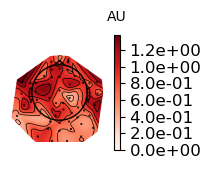

In [33]:
#plot tfrs
#choose anterior picks
"""
tfr_slow_neutral.plot(
    picks=['MEG45'], 
    baseline=[-0.500,-0.2], 
    mode="percent", 
    tmin=-0.5, tmax=1.0,
    title='MEG45')  
"""


tfr_slow_joy.plot_topomap(
    tmin=0.35, tmax=1, 
    fmin=4, fmax=7,
    baseline=[-0.5,-0.2], 
    mode="percent");